# Mumbai Traffic Dataset — Exploratory Data Analysis
Raw data sanity check before any preprocessing or model training.

In [2]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── PATHS — adjust if your folder structure differs ──────────────────────────
STATIC_PATH     = 'D:/Urban-Traffic-and-Parking-Analysis-using-LSTM-Autoencoders-and-Reinforcement-Learning/backend/data generation/data/static/edges_static.parquet'
TIMESERIES_GLOB = 'D:/Urban-Traffic-and-Parking-Analysis-using-LSTM-Autoencoders-and-Reinforcement-Learning/backend/data generation/data/timeseries/batch_*.parquet'

print('Loading static features …')
df_sta = pd.read_parquet(STATIC_PATH)
print(f'  Static  : {df_sta.shape}')

# Load first 3 batches for fast EDA (representative sample)
batches = sorted(glob.glob(TIMESERIES_GLOB))[:3]
print(f'Loading {len(batches)} timeseries batches (sample) …')
df_ts = pd.concat([pd.read_parquet(b) for b in batches], ignore_index=True)
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
print(f'  Timeseries sample : {df_ts.shape}')

# Join static for enriched analysis
df = df_ts.merge(df_sta[['edge_id','road_type','road_type_enc','num_lanes',
                          'road_length','corridor_id','zone_id',
                          'lat','lon']], on='edge_id', how='left')
print(f'  Joined shape      : {df.shape}')
print('Done.')

Loading static features …
  Static  : (145265, 17)
Loading 3 timeseries batches (sample) …
  Timeseries sample : (2520000, 25)
  Joined shape      : (2520000, 33)
Done.


In [3]:
print('=== STATIC FEATURES ===')
print(df_sta.dtypes.to_string())
print(f'\nShape : {df_sta.shape}')
df_sta.head(3)

=== STATIC FEATURES ===
edge_id                     str
u                         int64
v                         int64
lat                     float32
lon                     float32
road_type                   str
road_type_enc              int8
num_lanes                  int8
oneway                     bool
free_flow_speed         float32
road_length             float32
traffic_signal_count       int8
intersection_count         int8
signals_per_km          float32
susceptibility          float32
zone_id                   int32
corridor_id               int16

Shape : (145265, 17)


,edge_id,u,v,lat,lon,road_type,road_type_enc,num_lanes,oneway,free_flow_speed,road_length,traffic_signal_count,intersection_count,signals_per_km,susceptibility,zone_id,corridor_id
0,245654691_1034965549_0,245654691,1034965549,18.946730,72.832634,secondary,5,2,True,50.0,181.075745,1,1,5.522551,1.1,0,0
1,245654725_245654739_0,245654725,245654739,18.947941,72.795761,residential,2,1,False,30.0,53.579556,0,2,0.000000,0.7,1,0
2,245654725_245654775_0,245654725,245654775,18.947542,72.794823,residential,2,1,False,30.0,428.161469,0,2,0.000000,0.7,1,0


In [4]:
print('=== TIMESERIES FEATURES ===')
print(df_ts.dtypes.to_string())
print(f'\nShape : {df_ts.shape}')
df_ts.head(3)

=== TIMESERIES FEATURES ===
edge_id                              str
timestamp                 datetime64[us]
current_speed                    float32
free_flow_speed                  float32
current_travel_time              float32
free_flow_travel_time            float32
confidence                       float32
road_closure                        int8
incident                            int8
incident_type                       int8
incident_severity                   int8
incidents_nearby                   int16
hourly_rainfall_mm               float32
monsoon_active                      int8
local_train_disruption              int8
is_public_holiday                   int8
school_holiday                      int8
travel_time_ratio                float32
congestion_level                 float32
delay_seconds                    float32
speed_ratio                      float32
time_of_day_sin                  float32
time_of_day_cos                  float32
day_of_week_sin              

,edge_id,timestamp,current_speed,free_flow_speed,current_travel_time,free_flow_travel_time,confidence,road_closure,incident,incident_type,...,is_public_holiday,school_holiday,travel_time_ratio,congestion_level,delay_seconds,speed_ratio,time_of_day_sin,time_of_day_cos,day_of_week_sin,day_of_week_cos
0,245654691_1034965549_0,2024-07-01 00:00:00,45.360001,50.0,14.4,13.0,0.944,0,0,0,...,0,0,1.1022,0.0927,1.3,0.9073,0.00000,1.00000,0.0,1.0
1,245654691_1034965549_0,2024-07-01 01:00:00,46.139999,50.0,14.1,13.0,0.929,0,0,0,...,0,0,1.0837,0.0772,1.1,0.9228,0.25882,0.96593,0.0,1.0
2,245654691_1034965549_0,2024-07-01 02:00:00,46.369999,50.0,14.1,13.0,0.914,0,0,0,...,0,0,1.0783,0.0726,1.0,0.9274,0.50000,0.86603,0.0,1.0


In [5]:
print('=== MISSING VALUES (timeseries) ===')
miss = df_ts.isnull().sum()
print(miss[miss > 0] if miss.any() else 'No missing values — good!')

print('\n=== MISSING VALUES (static) ===')
miss2 = df_sta.isnull().sum()
print(miss2[miss2 > 0] if miss2.any() else 'No missing values — good!')

=== MISSING VALUES (timeseries) ===
No missing values — good!

=== MISSING VALUES (static) ===
No missing values — good!


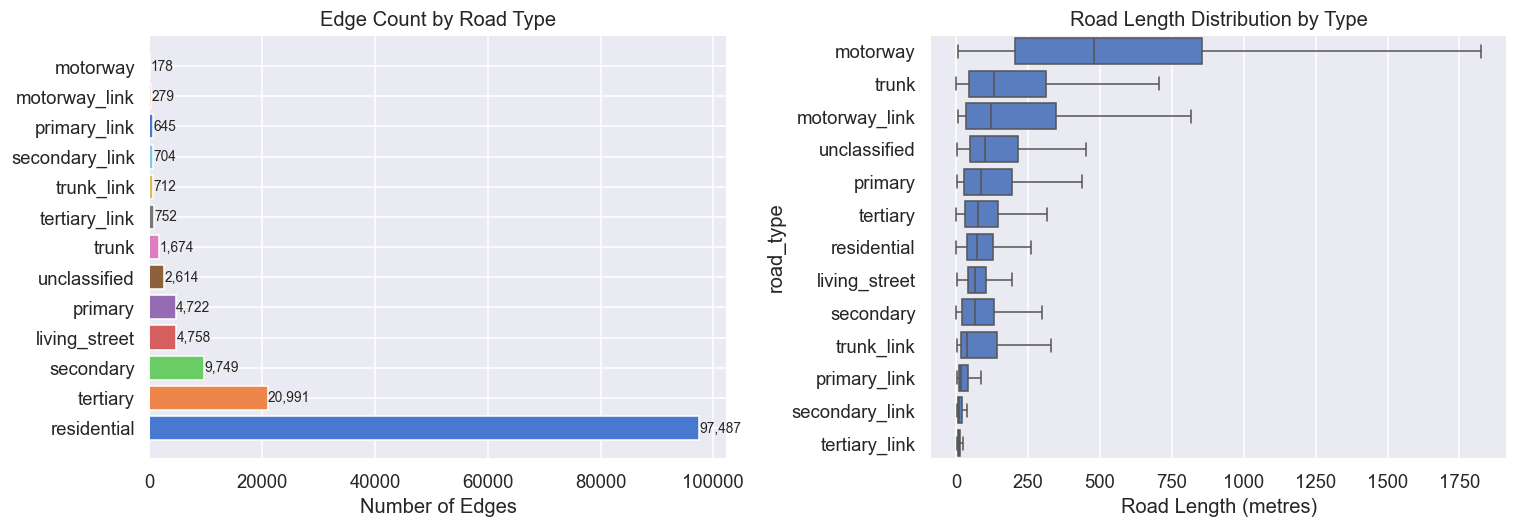

In [9]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Count per road type
# rt_counts = df_sta['road_type'].value_counts()
# axes[0].barh(rt_counts.index, rt_counts.values, color=sns.color_palette('muted', len(rt_counts)))
# axes[0].set_xlabel('Number of Edges')
# axes[0].set_title('Edge Count by Road Type')
# for i, v in enumerate(rt_counts.values):
#     axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# # Road length distribution per type
# order = df_sta.groupby('road_type')['road_length'].median().sort_values(ascending=False).index
# df_sta.boxplot(column='road_length', by='road_type', ax=axes[1],
#                order=order, vert=False, showfliers=False)
# axes[1].set_xlabel('Road Length (metres)')
# axes[1].set_title('Road Length Distribution by Type')
# plt.suptitle('')
# plt.tight_layout()
# plt.show()
# print(rt_counts.to_frame('count'))
# import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rt_counts = df_sta['road_type'].value_counts()
axes[0].barh(rt_counts.index, rt_counts.values,
             color=sns.color_palette('muted', len(rt_counts)))
axes[0].set_xlabel('Number of Edges')
axes[0].set_title('Edge Count by Road Type')

for i, v in enumerate(rt_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Boxplot (FIXED)
order = df_sta.groupby('road_type')['road_length'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_sta,
    x='road_length',
    y='road_type',
    order=order,
    ax=axes[1],
    showfliers=False
)

axes[1].set_xlabel('Road Length (metres)')
axes[1].set_title('Road Length Distribution by Type')

plt.tight_layout()
plt.show()

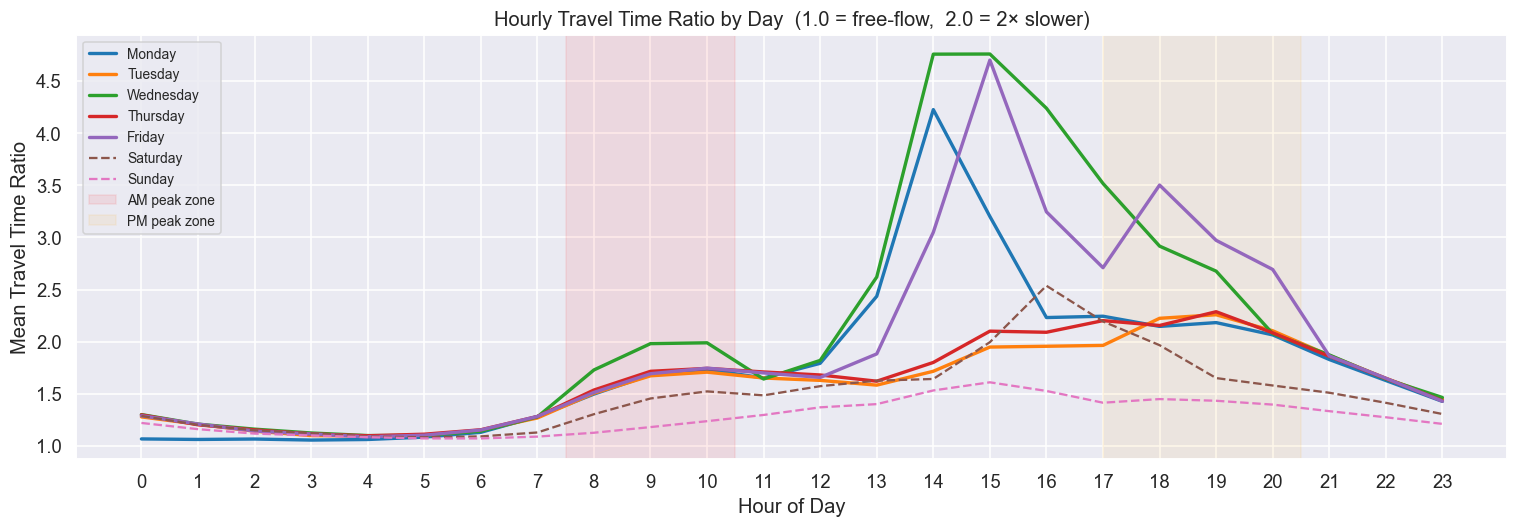

Peak hours summary:
day_name   hour
Friday     8       1.514
           9       1.693
           18      3.502
           19      2.972
Monday     8       1.498
           9       1.682
           18      2.147
           19      2.183
Saturday   8       1.305
           9       1.456
           18      1.967
           19      1.652
Sunday     8       1.127
           9       1.182
           18      1.450
           19      1.434
Thursday   8       1.537
           9       1.716
           18      2.156
           19      2.288
Tuesday    8       1.506
           9       1.673
           18      2.224
           19      2.258
Wednesday  8       1.729
           9       1.982
           18      2.916
           19      2.676


In [8]:
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek   # 0=Mon … 6=Sun
df['day_name']  = df['timestamp'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Mean travel_time_ratio per hour × day
pivot = df.pivot_table(values='travel_time_ratio', index='hour',
                        columns='day_name', aggfunc='mean')[day_order]

fig, ax = plt.subplots(figsize=(14, 5))
colors = sns.color_palette('tab10', 7)
for i, day in enumerate(day_order):
    ls = '--' if day in ('Saturday','Sunday') else '-'
    lw = 1.5 if day in ('Saturday','Sunday') else 2.2
    ax.plot(pivot.index, pivot[day], label=day, color=colors[i], ls=ls, lw=lw)

ax.axvspan(7.5, 10.5, alpha=0.08, color='red',   label='AM peak zone')
ax.axvspan(17, 20.5,  alpha=0.08, color='orange', label='PM peak zone')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Travel Time Ratio')
ax.set_title('Hourly Travel Time Ratio by Day  (1.0 = free-flow,  2.0 = 2× slower)')
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Peak hours summary:')
print(df[df['hour'].isin([8,9,18,19])]
      .groupby(['day_name','hour'])['travel_time_ratio']
      .mean().round(3).to_string())

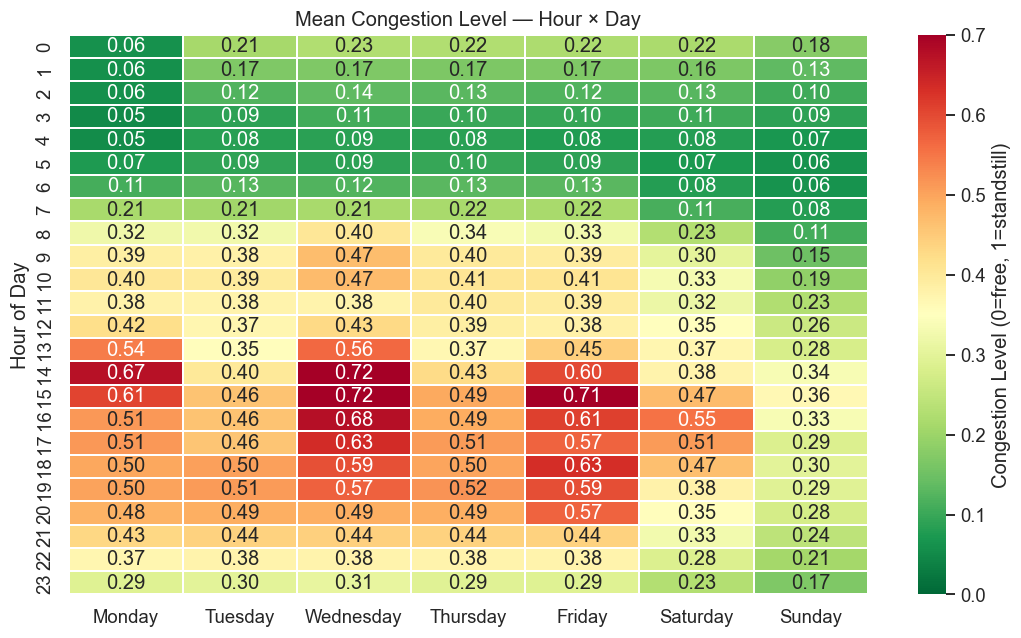

In [10]:
# Congestion heatmap — hour × day
pivot2 = df.pivot_table(values='congestion_level', index='hour',
                         columns='day_name', aggfunc='mean')[day_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot2, cmap='RdYlGn_r', annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, vmin=0, vmax=0.7,
            cbar_kws={'label': 'Congestion Level (0=free, 1=standstill)'})
ax.set_title('Mean Congestion Level — Hour × Day')
ax.set_xlabel('')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.show()

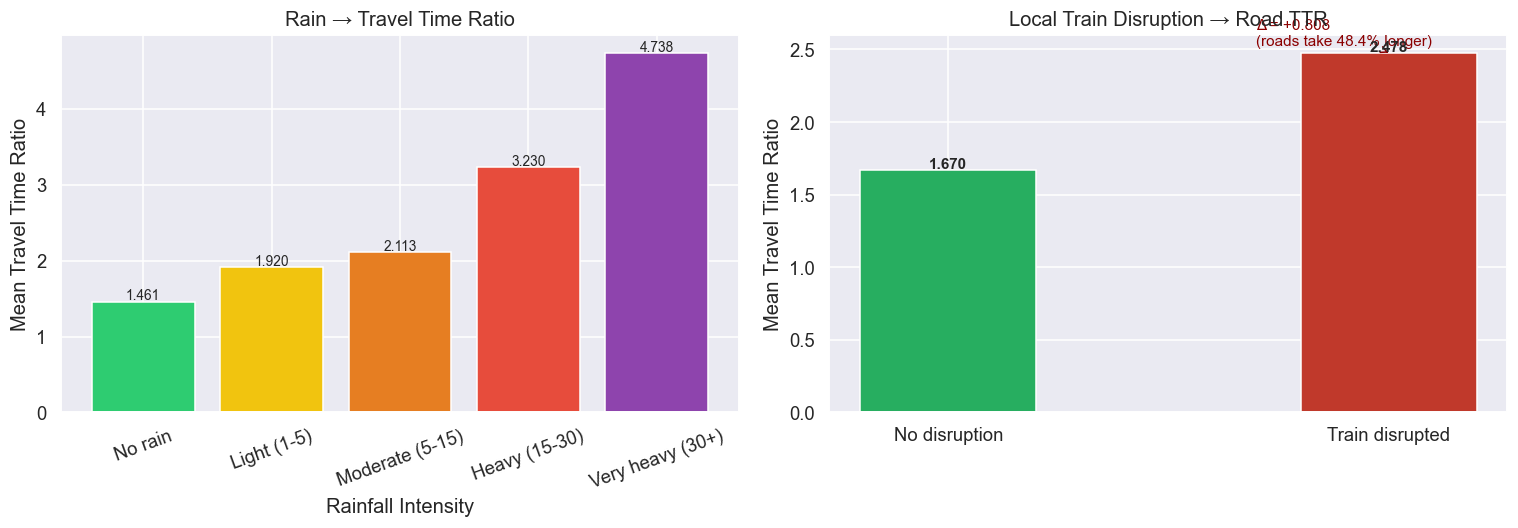

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Rain effect ───────────────────────────────────────────────────────────────
rain_bins = pd.cut(df['hourly_rainfall_mm'],
                   bins=[-0.1, 0.5, 5, 15, 30, 100],
                   labels=['No rain','Light (1-5)','Moderate (5-15)',
                            'Heavy (15-30)','Very heavy (30+)'])
rain_effect = df.groupby(rain_bins, observed=True)['travel_time_ratio'].mean()

bars = axes[0].bar(rain_effect.index, rain_effect.values,
                   color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad'])
axes[0].set_xlabel('Rainfall Intensity')
axes[0].set_ylabel('Mean Travel Time Ratio')
axes[0].set_title('Rain → Travel Time Ratio')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, rain_effect.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.3f}', ha='center', fontsize=9)

# ── Train disruption effect ───────────────────────────────────────────────────
td_effect = df.groupby('local_train_disruption')['travel_time_ratio'].mean()
bars2 = axes[1].bar(['No disruption','Train disrupted'],
                    td_effect.values, color=['#27ae60','#c0392b'], width=0.4)
axes[1].set_ylabel('Mean Travel Time Ratio')
axes[1].set_title('Local Train Disruption → Road TTR')
diff = td_effect[1] - td_effect[0]
axes[1].annotate(f'Δ = +{diff:.3f}\n(roads take {diff/td_effect[0]*100:.1f}% longer)',
                 xy=(1, td_effect[1]), xytext=(0.7, td_effect[1] + 0.05),
                 fontsize=10, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'))
for bar, v in zip(bars2, td_effect.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

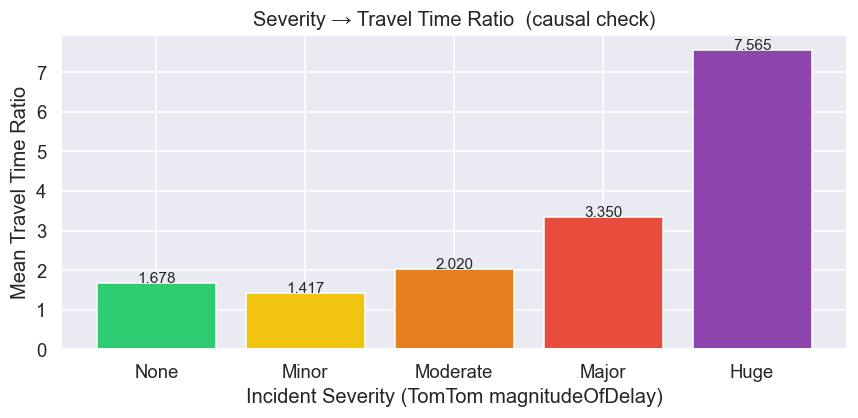

Monotonically increasing? False


In [14]:
# Does incident_severity actually correlate with travel_time_ratio?
fig, ax = plt.subplots(figsize=(8, 4))
sev_ttr = df.groupby('incident_severity')['travel_time_ratio'].mean()
ax.bar([sev_map.get(i, str(i)) for i in sev_ttr.index], sev_ttr.values,
       color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad'])
ax.set_xlabel('Incident Severity (TomTom magnitudeOfDelay)')
ax.set_ylabel('Mean Travel Time Ratio')
ax.set_title('Severity → Travel Time Ratio  (causal check)')
for i, v in enumerate(sev_ttr.values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Monotonically increasing?', all(np.diff(sev_ttr.values) > 0))

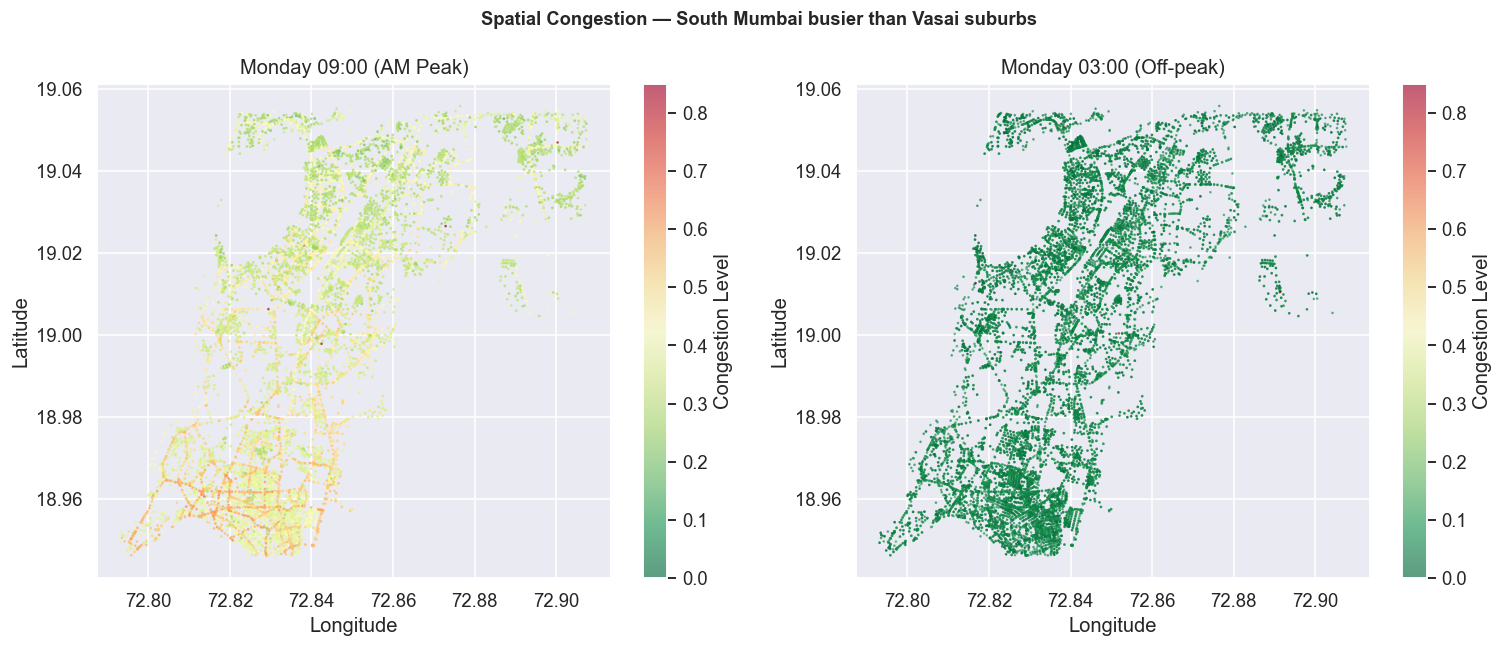

North (Vasai area, lat>19.3) vs South (Churchgate area, lat<19.05) avg congestion:
  North avg : nan
  South avg : 0.390
  Ratio S/N : nanx  (South should be ~1.5-2x busier)


In [16]:
# Sample one specific hour (Monday 9am — peak) for spatial view
peak_hour = df[(df['day_name']=='Monday') & (df['hour']==9)].copy()
off_hour  = df[(df['day_name']=='Monday') & (df['hour']==3)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, d, title in zip(axes,
                         [peak_hour, off_hour],
                         ['Monday 09:00 (AM Peak)', 'Monday 03:00 (Off-peak)']):
    sc = ax.scatter(d['lon'], d['lat'], c=d['congestion_level'],
                    cmap='RdYlGn_r', s=0.5, alpha=0.6, vmin=0, vmax=0.85)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label='Congestion Level')

plt.suptitle('Spatial Congestion — South Mumbai busier than Vasai suburbs',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('North (Vasai area, lat>19.3) vs South (Churchgate area, lat<19.05) avg congestion:')
north = peak_hour[peak_hour['lat'] > 19.30]['congestion_level'].mean()
south = peak_hour[peak_hour['lat'] < 19.05]['congestion_level'].mean()
print(f'  North avg : {north:.3f}')
print(f'  South avg : {south:.3f}')
print(f'  Ratio S/N : {south/north:.2f}x  (South should be ~1.5-2x busier)')